In [ ]:
#imports
import os
import cv2 # type: ignore
import shutil
import numpy as np # type: ignore
import ipywidgets as widgets # type: ignore
import matplotlib.pyplot as plt # type: ignore
import time
import subprocess

from IPython.display import display, HTML, clear_output # type: ignore
from datetime import datetime
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from statistics import mean

!apt-get update -qq
!apt-get install -y ffmpeg -qq

from google.colab import drive # type: ignore
drive.mount('/content/drive')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Mounted at /content/drive


In [ ]:
#define paths
INPUT_FOLDER = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files'
OUTPUT_FOLDER = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Cropped Ultrasound Files'

REFERENCE_IMAGE1 = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/NP008/NP008_Abd/capture_4_2026-01-13T17-25-17.jpeg'
REFERENCE_IMAGE2 = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/P034/T2/P034_Abd_T2/capture_6_2026-04-30T10-58-48.jpeg'

FOLDER_PATH = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files'


# Cropping

In [ ]:
#crop non-abd


def is_abd(file_path):
  """
  Check if a file is an abdomen ultrasound image or video.
  """
  folder_segments = file_path.parent.name.split('_')
  return "Abd" in folder_segments


def crop_frame(frame):
  """
  Returns crop coordinates of a frame
  """

  #get frame dimensions
  h_orig, w_orig = frame.shape[:2]

  #convert to grayscale
  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

  #create a binary mask where non-black pixels are white
  _, binary = cv2.threshold(gray, 5, 255, cv2.THRESH_BINARY) #threshold set to 10 for stricter black removal

  #ignore graphics on the sides by only using the middle 81.8% of the mask
  side_margin = int(w_orig * 0.091)
  binary[:, :side_margin] = 0 #erase left 9.1%
  binary[:, w_orig - side_margin:] = 0 #erase right 9.1%

  #find coordinates of non-black pixels
  coords = cv2.findNonZero(binary) #returns x, y coordinates of all non-black pixels
  if coords is None:
    return None

  #get the bounding box of the non-black area
  x, y, w, h = cv2.boundingRect(coords)

  x_start = max(0, x)
  y_start = max(0, y)
  x_end = min(w_orig, x + w)
  y_end = min(h_orig, y + h)

  #return cropping coords
  return x_start, y_start, x_end, y_end


def crop_dataset(source_base, target_base):
  source_path = Path(source_base)
  target_path = Path(target_base)

  CUTOFF_DATE = datetime(2026, 6, 20)

  #extensions we want to process
  IMAGE_EXTS = ('.jpeg', '.jpg')
  VIDEO_EXTS = ('.mp4',)

  for root, dirs, files in os.walk(source_path):
    for file in files:
      file_path = Path(root) / file
      ext = file_path.suffix.lower()

      #skip hidden files
      if file.startswith('.'):
        continue

      #skip abd files
      if is_abd(file_path):
        continue

      #skip old files
      if datetime.fromtimestamp(file_path.stat().st_mtime) < CUTOFF_DATE:
        continue

      #create matching folder structure
      relative_path = file_path.relative_to(source_path)

      output_path = target_path / relative_path
      output_path.parent.mkdir(parents=True, exist_ok=True)


      #process media
      try:
        #process images
        if ext in IMAGE_EXTS:
          image = cv2.imread(str(file_path))
          if image is None:
            print(f"Error: Unable to load image {file_path}")
            continue

          crop_coords = crop_frame(image)
          if crop_coords is None:
            print(f"Error: Unable to crop image, skipping: {relative_path}")

          x_start, y_start, x_end, y_end = crop_coords
          cropped_image = image[y_start:y_end, x_start:x_end]
          success = cv2.imwrite(str(output_path), cropped_image)
          if success:
            print(f"Cropped image: {relative_path}")
          else:
            print(f"Failed to save image: {relative_path}")

        #process videos
        elif ext in VIDEO_EXTS:
          cap = cv2.VideoCapture(str(file_path))
          if not cap.isOpened():
            print(f"Error: Unable to open video {file_path}")
            continue

          fps = cap.get(cv2.CAP_PROP_FPS)

          ret, first_frame = cap.read()
          if not ret or first_frame is None:
            print(f"Error: Unable to read first frame from video {file_path}")
            cap.release()
            continue

          crop_coords = crop_frame(first_frame)
          if crop_coords is None:
            print(f"Error: Unable to crop video, skipping: {relative_path}")
            cap.release()
            continue

          x_start, y_start, x_end, y_end = crop_coords

          fourcc = cv2.VideoWriter_fourcc(*'mp4v')
          out = cv2.VideoWriter(str(output_path), fourcc, fps, (x_end - x_start, y_end - y_start))

          #write cropped first frame
          out.write(first_frame[y_start:y_end, x_start:x_end])

          #apply same coordinates to all remaining frames
          while True:
            ret, frame = cap.read()
            if not ret:
              break #end of video
            #crop and write frame
            out.write(frame[y_start:y_end, x_start:x_end])

          cap.release()
          out.release()
          print(f"Cropped video: {relative_path}")

      except Exception as e:
        print(f"Skipped {file} due to error: {e}")

#Run
crop_dataset(INPUT_FOLDER, OUTPUT_FOLDER)

Cropped image: P046/T2/P046_Bicep_T2/capture_3_2026-05-19T11-04-00.jpeg
Cropped image: P046/T2/P046_Bicep_T2/capture_1_2026-05-19T11-03-59.jpeg
Cropped image: P046/T2/P046_Bicep_T2/capture_2_2026-05-19T11-04-00.jpeg
Cropped video: P046/T2/P046_Bicep_T2/capture_4_2026-05-19T11-04-19.mp4
Cropped video: P046/T2/P046_Bicep_T2/capture_5_2026-05-19T11-04-31.mp4
Cropped video: P046/T2/P046_Bicep_T2/capture_6_2026-05-19T11-04-44.mp4
Cropped image: P046/T2/P046_Scap_T2/capture_1_2026-05-19T11-06-17.jpeg
Cropped image: P046/T2/P046_Scap_T2/capture_2_2026-05-19T11-06-18.jpeg
Cropped image: P046/T2/P046_Scap_T2/capture_3_2026-05-19T11-06-19.jpeg
Cropped video: P046/T2/P046_Scap_T2/capture_4_2026-05-19T11-06-32.mp4
Cropped video: P046/T2/P046_Scap_T2/capture_5_2026-05-19T11-06-47.mp4
Cropped video: P046/T2/P046_Scap_T2/capture_6_2026-05-19T11-07-02.mp4
Cropped image: P046/T2/P046_Quad_T2/capture_2_2026-05-19T11-08-33.jpeg
Cropped image: P046/T2/P046_Quad_T2/capture_1_2026-05-19T11-08-32.jpeg
Croppe

In [ ]:
#crop abd

REFERENCE_IMAGE1 = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/NP008/NP008_Abd/capture_4_2026-01-13T17-25-17.jpeg'
REFERENCE_IMAGE2 = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/P034/T2/P034_Abd_T2/capture_6_2026-04-30T10-58-48.jpeg'

def is_abd(file_path):
  """
  Check if a file is an abdomen ultrasound image or video.
  """
  folder_segments = file_path.parent.name.split('_')
  return "Abd" in folder_segments

def is_blue_tinted(image):
  """
  Returns True if the image has color saturation (Ref1 type),
  False if grayscale/no saturation (Ref2 and Ref3 type).
  """
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
  fan_hsv = hsv[gray > 10]
  if len(fan_hsv) == 0:
    return False
  sat_mean = fan_hsv[:, 1].mean()
  return (sat_mean > 20) #tune if needed

def is_MSK(file_path):
  """
  Returns True if the image was an MSK scan (Ref3 type),
  False otherwise (Ref2 type).
  """
  #image path in (T1 P001 P005 P006, T2 P054 P055 P059 P060 P062, NP015)
  MSK_FOLDERS = [
  'NP015_Abd',
  'P001_Abd_T1',
  'P005_Abd_T1',
  'P006_Abd_T1',
  'P054_Abd_T2',
  'P055_Abd_T2',
  'P059_Abd_T2',
  'P060_Abd_T2',
  'P062_Abd_T2',
  # add more as needed
  ]
  return file_path.parent.name in MSK_FOLDERS

def get_logo_coords(reference):
  """
  Return bounding rect coords of logo.
  HSV bounds for Clarius logo - tune after testing (1st saturation 150+)
  hue: 0-15 (red-orange), saturation: 100-255, value: 10-220
  """
  #ref_clean = reference.copy()
  hsv = cv2.cvtColor(reference, cv2.COLOR_BGR2HSV)
  lower = np.array([0, 10, 10], dtype = np.uint8)
  upper = np.array([15, 255, 255], dtype = np.uint8)
  logo_mask = cv2.inRange(hsv, lower, upper).astype(bool)

  coords = cv2.findNonZero(logo_mask.astype(np.uint8))
  if coords is None:
    return None

  return cv2.boundingRect(coords)

def compute_fan_mask(reference_path):
  """
  Detect and remove logo from reference image.
  Compute a filled fan mask and bounding rect from reference image.
  Return a boolean mask (fan_mask_bool, x, y, w, h).
  """

  ref = cv2.imread(str(reference_path))
  if ref is None:
    raise ValueError(f"Could not load reference image: {reference_path}")

  h, w = ref.shape[:2]
  ref_clean = ref.copy()

  logo_coords = get_logo_coords(ref_clean)
  if logo_coords is not None:
    lx, ly, lw, lh = logo_coords
    ref_clean[ly:ly+lh, lx:lx+lw] = 0

  # zero out ruler on the right: scan columns from right until bright pixels found
  gray_right = cv2.cvtColor(ref_clean, cv2.COLOR_BGR2GRAY)
  ruler_col = w  # default: no ruler found
  for col in range(w - 1, int(w * 0.7), -1):
    if (gray_right[:, col] > 200).sum() > 5:
      ruler_col = col
      break
  ref_clean[:, max(0, ruler_col - 20):] = 0

  # threshold to find fan region
  gray_clean = cv2.cvtColor(ref_clean, cv2.COLOR_BGR2GRAY)
  _, binary = cv2.threshold(gray_clean, 5, 255, cv2.THRESH_BINARY)

  # find largest contour — this is the fan
  contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  if not contours:
    raise ValueError(f"Could not detect fan contour in reference image: {reference_path}")

  largest = max(contours, key=cv2.contourArea)
  x, y, bw, bh = cv2.boundingRect(largest)

  # build filled fan mask (True inside the fan contour)
  fan_mask = np.zeros((h, w), dtype=np.uint8)
  cv2.drawContours(fan_mask, [largest], -1, 255, thickness=cv2.FILLED)

  print(f"Fan mask computed from {reference_path}: bounding rect x={x}, y={y}, w={bw}, h={bh}")
  return fan_mask.astype(bool), x, y, bw, bh


def process_abd_frame(frame, fan_mask, x, y, bw, bh, logo_coords):
  """
  Apply fan mask to a single frame and crop to bounding rect.
  Return cropped frame.
  """
  result = frame.copy()

  #remove logo
  if logo_coords is not None:
    lx, ly, lw, lh = logo_coords
    result[ly:ly+lh, lx:lx+lw] = 0

  # set everything outside the fan to white
  #result[~fan_mask] = 255

  # crop to bounding rect
  return result[y:y+bh, x:x+bw]


def process_abd(source_base, target_base, reference_path1, reference_path2):
  source_path = Path(source_base)
  target_path = Path(target_base)

  CUTOFF_DATE = datetime(2026, 7, 09)

  #extensions we want to process
  IMAGE_EXTS = ('.jpeg', '.jpg')
  VIDEO_EXTS = ('.mp4',)

  #compute boths masks once
  fan_mask1, fx1, fy1, fbw1, fbh1 = compute_fan_mask(reference_path1)
  fan_mask2, fx2, fy2, fbw2, fbh2 = compute_fan_mask(reference_path2)
  ref1 = cv2.imread(str(reference_path1))
  ref2 = cv2.imread(str(reference_path2))
  ref1_h, ref1_w = ref1.shape[:2]
  ref2_h, ref2_w = ref2.shape[:2]

  #initialize MSK references
  reference_path3 = None
  fan_mask3 = fx3 = fy3 = fbw3 = fbh3 = None

  for root, dirs, files in os.walk(source_path):
    for file in files:
      file_path = Path(root) / file
      ext = file_path.suffix.lower()

      #skip hidden files
      if file.startswith('.'):
        continue

      #skip non abd files
      if not is_abd(file_path):
        continue

      #skip old files
      # if datetime.fromtimestamp(file_path.stat().st_mtime) < CUTOFF_DATE:
      #   continue

      #create matching folder structure
      relative_path = file_path.relative_to(source_path)
      output_path = target_path / relative_path
      output_path.parent.mkdir(parents=True, exist_ok=True)

      #check if the cropped file already exists
      if output_path.exists():
          print(f"File already processed: {relative_path}")
          continue

      #process media
      try:
        #process abd images
        if ext in IMAGE_EXTS:
          image = cv2.imread(str(file_path))
          if image is None:
            print(f"Error: Unable to load image {file_path}")
            continue

          h, w = image.shape[:2]
          #get image logo coords
          logo_coords = get_logo_coords(image)

          #check for image tint
          if is_blue_tinted(image):
            if h != ref1_h or w != ref1_w: ##comment out if all sizes are correct
              print(f"Skipped (size mismatch {w}x{h} vs ref1 {ref1_w}x{ref1_h}): {relative_path}")
              continue
            fan_mask, fx, fy, fbw, fbh = fan_mask1, fx1, fy1, fbw1, fbh1
          elif is_MSK(file_path):
            if reference_path3 is not None and file_path.parent.name == reference_path3.parent.name:
              fan_mask, fx, fy, fbw, fbh = fan_mask3, fx3, fy3, fbw3, fbh3
            else:
              reference_path3 = file_path
              fan_mask3, fx3, fy3, fbw3, fbh3 = compute_fan_mask(reference_path3)
              fan_mask, fx, fy, fbw, fbh = fan_mask3, fx3, fy3, fbw3, fbh3
          else:
            if h != ref2_h or w != ref2_w: ##comment out if all sizes are correct
              print(f"Skipped (size mismatch {w}x{h} vs ref2 {ref2_w}x{ref2_h}): {relative_path}")
              continue
            fan_mask, fx, fy, fbw, fbh = fan_mask2, fx2, fy2, fbw2, fbh2

          processed = process_abd_frame(image, fan_mask, fx, fy, fbw, fbh, logo_coords)
          success = cv2.imwrite(str(output_path), processed)
          if success:
            print(f"Processed Abd image: {relative_path}")
          else:
            print(f"Failed to process Abd image: {relative_path}")

        #process abd videos
        elif ext in VIDEO_EXTS:
          cap = cv2.VideoCapture(str(file_path))
          if not cap.isOpened():
            print(f"Error: Unable to open video {file_path}")
            continue

          fps = cap.get(cv2.CAP_PROP_FPS)
          w_orig = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
          h_orig = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

          ret, first_frame = cap.read()
          if not ret or first_frame is None:
            print(f"Error: Unable to read first frame from video {file_path}")
            cap.release()
            continue
          #get video logo coords once
          logo_coords = get_logo_coords(first_frame)

          #check for video tint
          if is_blue_tinted(first_frame):
            if h_orig != ref1_h or w_orig != ref1_w: ##comment out if all sizes are correct
              print(f"Skipped (size mismatch {w_orig}x{h_orig} vs ref {ref1_w}x{ref1_h}): {relative_path}")
              cap.release()
              continue
            fan_mask, fx, fy, fbw, fbh = fan_mask1, fx1, fy1, fbw1, fbh1
          elif is_MSK(file_path):
            if reference_path3 is not None and file_path.parent.name == reference_path3.parent.name:
              fan_mask, fx, fy, fbw, fbh = fan_mask3, fx3, fy3, fbw3, fbh3
            else:
              reference_path3 = file_path
              fan_mask3, fx3, fy3, fbw3, fbh3 = compute_fan_mask(reference_path3)
              fan_mask, fx, fy, fbw, fbh = fan_mask3, fx3, fy3, fbw3, fbh3
          else:
            if h_orig != ref2_h or w_orig != ref2_w: ##comment out if all sizes are correct
              print(f"Skipped (size mismatch {w_orig}x{h_orig} vs ref2 {ref2_w}x{ref2_h}): {relative_path}")
              cap.release()
              continue
            fan_mask, fx, fy, fbw, fbh = fan_mask2, fx2, fy2, fbw2, fbh2

          temp_path = output_path.with_suffix('.temp.mp4')
          fourcc = cv2.VideoWriter_fourcc(*'mp4v')
          out = cv2.VideoWriter(str(temp_path), fourcc, fps, (fbw, fbh))

          #process first frame
          out.write(process_abd_frame(first_frame, fan_mask, fx, fy, fbw, fbh, logo_coords))

          #process remaining frames
          while True:
            ret, frame = cap.read()
            if not ret:
              break #end of video
            out.write(process_abd_frame(frame, fan_mask, fx, fy, fbw, fbh, logo_coords))

          cap.release()
          out.release()

          temp_path.replace(output_path)
          print(f"Processed Abd video: {relative_path}")

      except Exception as e:
        print(f"Skipped {file_path} due to error: {e}")


#Run
process_abd(INPUT_FOLDER, OUTPUT_FOLDER, REFERENCE_IMAGE1, REFERENCE_IMAGE2)

Fan mask computed from /content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/NP008/NP008_Abd/capture_4_2026-01-13T17-25-17.jpeg: bounding rect x=156, y=140, w=712, h=489
Fan mask computed from /content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/P034/T2/P034_Abd_T2/capture_6_2026-04-30T10-58-48.jpeg: bounding rect x=130, y=121, w=766, h=526
File already processed: P015/T1/P015_Abd_T1/capture_4_2025-12-22T16-34-49.jpeg
File already processed: P015/T1/P015_Abd_T1/capture_3_2025-12-22T16-34-43.jpeg
File already processed: P015/T1/P015_Abd_T1/capture_5_2025-12-22T16-34-50.jpeg
File already processed: P015/T1/P015_Abd_T1/capture_6_2025-12-22T16-34-56.jpeg
File already processed: P015/T1/P015_Abd_T1/capture_1_2025-12-22T16-34-41.jpeg
File already processed: P015/T1/P015_Abd_T1/capture_2_2025-12-22T16-34-42.jpeg
File already processed: P015/T1/P015_Abd_T1/capture_8_2025-12-22T16-34-59.jpeg
File already processed: P015/T1/P015_Abd_T1/capture_7_2025-12-22T

In [ ]:
# crop non abd frames from videos
# Crops bad contact black regions on left/right edges if needed.
# Overwrites image in place. Skips images that don't need cropping.

INPUT_FOLDER = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Cropped Ultrasound Files'

CONTENT_THRESHOLD = 175  # tune if needed — real content has 400+, bad contact has <100

def is_abd(file_path):
  folder_segments = file_path.parent.name.split('_')
  return "Abd" in folder_segments

def crop_frame_contacts(frame):
  """
  Detect bad-contact regions on left and right edges and crop them.
  Returns (cropped_frame, was_cropped).
  """
  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
  h, w = gray.shape

  # scan from right
  right_crop = w
  for col in range(w - 1, 20, -1):
    nonblack = (gray[:, col] > 10).sum()
    if nonblack >= CONTENT_THRESHOLD:
      right_crop = col + 1
      break

  # scan from left
  left_crop = 0
  for col in range(0, w - 20):
    nonblack = (gray[:, col] > 10).sum()
    if nonblack >= CONTENT_THRESHOLD:
      left_crop = col
      break

  was_cropped = (left_crop > 0) or (right_crop < w)
  cropped = frame[:, left_crop:right_crop]
  #cropped = frame
  return cropped, was_cropped, left_crop, right_crop

def crop_contact_images(source_base):
  source_path = Path(source_base)

  IMAGE_EXTS = ('.jpeg', '.jpg')

  for root, dirs, files in os.walk(source_path):
    for file in files:
      file_path = Path(root) / file
      ext = file_path.suffix.lower()

      # skip hidden files
      if file.startswith('.'):
        continue

      # skip non-images
      if ext not in IMAGE_EXTS:
        continue

      #skip abd files
      if is_abd(file_path):
        continue

      try:
        image = cv2.imread(str(file_path))
        if image is None:
          print(f"Error: Unable to load image {file_path}")
          continue

        cropped, was_cropped, left_crop, right_crop = crop_frame_contacts(image)
        if not was_cropped:
          print(f"No cropping needed: {file_path.relative_to(source_path)}")
          continue
        success = cv2.imwrite(str(file_path), cropped)
        if success:
          print(f"Cropped: {file_path.relative_to(source_path)} - left: {left_crop}px, right: {(image.shape[1] - right_crop)}px")
        else:
          print(f"Failed to save: {file_path.relative_to(source_path)}")

      except Exception as e:
        print(f"Skipped {file} due to error: {e}")

# Run
crop_contact_images(INPUT_FOLDER)

Cropped: NP001/NP001_Bicep/capture_3_2025-12-09T15-12-38.jpeg - left: 1px, right: 3px
Cropped: NP001/NP001_Bicep/capture_2_2025-12-09T15-12-36.jpeg - left: 2px, right: 3px
Cropped: NP001/NP001_Bicep/capture_1_2025-12-09T15-12-34.jpeg - left: 0px, right: 1px
Cropped: NP001/NP001_Quad/capture_3_2025-12-09T15-18-26.jpeg - left: 3px, right: 1px
Cropped: NP001/NP001_Quad/capture_2_2025-12-09T15-18-23.jpeg - left: 0px, right: 2px
Cropped: NP001/NP001_Quad/capture_1_2025-12-09T15-18-20.jpeg - left: 2px, right: 1px
Cropped: NP001/NP001_Scap/capture_3_2025-12-09T15-15-36.jpeg - left: 0px, right: 1px
Cropped: NP001/NP001_Scap/capture_2_2025-12-09T15-15-32.jpeg - left: 3px, right: 1px
Cropped: NP001/NP001_Scap/capture_1_2025-12-09T15-15-27.jpeg - left: 2px, right: 1px
Cropped: NP005/NP005_Quad/capture_3_2025-12-20T10-53-46.jpeg - left: 2px, right: 1px
Cropped: NP005/NP005_Quad/capture_2_2025-12-20T10-53-43.jpeg - left: 2px, right: 2px
Cropped: NP005/NP005_Quad/capture_1_2025-12-20T10-53-40.jpeg -

# Tests


In [ ]:
#save 3 frames from each video in Test Files/Videos

# Step 2: Define paths and target times (in seconds)
INPUT_FOLDER = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Test Files/Videos'
OUTPUT_FOLDER = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Test Files/Frames'
TARGET_TIMES = [1, 4, 9]  # Seconds to extract

# Ensure the output directory exists
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Supported video extensions
VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv', '.wmv')

# Step 3: Process the videos
video_files = [f for f in os.listdir(INPUT_FOLDER) if f.lower().endswith(VIDEO_EXTENSIONS)]

if not video_files:
    print(f"No videos found in {INPUT_FOLDER}")
else:
    print(f"Found {len(video_files)} videos. Starting extraction...")

for video_name in video_files:
    video_path = os.path.join(INPUT_FOLDER, video_name)
    base_name = os.path.splitext(video_name)[0]

    # Open the video file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_name}")
        continue

    # Get total frames and Frame Rate (FPS) to check video duration
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = total_frames / fps if fps > 0 else 0

    print(f"\nProcessing: {video_name} ({duration:.2f}s total)")

    for sec in TARGET_TIMES:
        if sec > duration:
            print(f"  -> Skipped {sec}s frame (video is too short).")
            continue

        # Calculate the exact frame index to jump to
        frame_index = int(sec * fps)

        # Set the video position to the specific frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

        # Read the frame
        success, frame = cap.read()

        if success:
            # Construct output filename (e.g., videoName_1s.jpg)
            output_name = f"{base_name}_{sec}s.jpg"
            output_path = os.path.join(OUTPUT_FOLDER, output_name)

            # Save the frame
            cv2.imwrite(output_path, frame)
            print(f"  -> Saved: {output_name}")
        else:
            print(f"  -> Failed to extract frame at {sec}s")

    # Release the video object for the next iteration
    cap.release()

print("\nProcessing complete!")

Found 3 videos. Starting extraction...

Processing: capture_4_2025-12-12T11-12-13.mp4 (10.00s total)
  -> Saved: capture_4_2025-12-12T11-12-13_1s.jpg
  -> Saved: capture_4_2025-12-12T11-12-13_4s.jpg
  -> Saved: capture_4_2025-12-12T11-12-13_9s.jpg

Processing: capture_5_2026-01-13T17-36-20.mp4 (9.96s total)
  -> Saved: capture_5_2026-01-13T17-36-20_1s.jpg
  -> Saved: capture_5_2026-01-13T17-36-20_4s.jpg
  -> Saved: capture_5_2026-01-13T17-36-20_9s.jpg

Processing: capture_4_2026-02-02T10-26-21.mp4 (10.04s total)
  -> Saved: capture_4_2026-02-02T10-26-21_1s.jpg
  -> Saved: capture_4_2026-02-02T10-26-21_4s.jpg
  -> Saved: capture_4_2026-02-02T10-26-21_9s.jpg

Processing complete!


Image Dimensions: Height=488, Width=814
Max non-black pixels in a column: 388
Min non-black pixels in a column: 0
Target Threshold: 200

Debug plot saved to 'crop_debug_profile.png'. Open this file to analyze the curve!


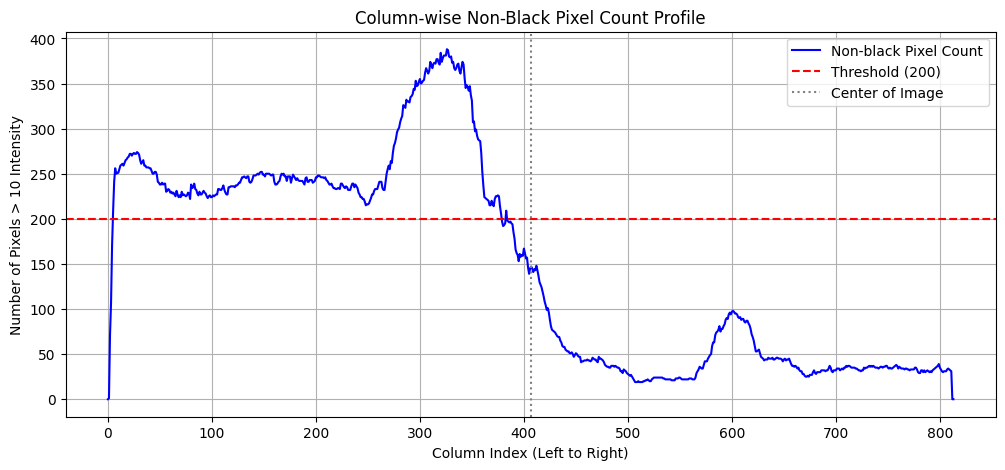

In [ ]:
#debug video frame cropping

import cv2 # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore

REFERENCE_IMAGE = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Test Files/Frames/capture_4_2025-12-12T11-12-13_9s.jpg'
CONTENT_THRESHOLD = 200

def debug_image_profile(image_path, threshold=200, intensity_cutoff=10):
    # Load image
    frame = cv2.imread(image_path)
    if frame is None:
        print("Error: Could not load image.")
        return

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # Calculate non-black pixels for every column
    nonblack_counts = [(gray[:, col] > intensity_cutoff).sum() for col in range(w)]

    # Print some key stats to console
    print(f"Image Dimensions: Height={h}, Width={w}")
    print(f"Max non-black pixels in a column: {max(nonblack_counts)}")
    print(f"Min non-black pixels in a column: {min(nonblack_counts)}")
    print(f"Target Threshold: {threshold}")

    # Plot the profile
    plt.figure(figsize=(12, 5))
    plt.plot(nonblack_counts, label='Non-black Pixel Count', color='blue')
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
    plt.axvline(x=w//2, color='gray', linestyle=':', label='Center of Image')

    plt.title('Column-wise Non-Black Pixel Count Profile')
    plt.xlabel('Column Index (Left to Right)')
    plt.ylabel('Number of Pixels > 10 Intensity')
    plt.legend()
    plt.grid(True)

    # Save the debug plot
    output_plot_path = 'crop_debug_profile.png'
    plt.savefig(output_plot_path)
    print(f"\nDebug plot saved to '{output_plot_path}'. Open this file to analyze the curve!")

# Replace with the path to your specific problematic image
debug_image_profile(REFERENCE_IMAGE, threshold=CONTENT_THRESHOLD)

In [ ]:
#check video lengths


IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".gif", ".bmp", ".tiff", ".webp"}
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm", ".flv", ".m4v"}

EXPECTED_DURATION = 10.0
TOLERANCE = 0.25
MAX_WORKERS = 8  # Tune based on your CPU/IO

CUTOFF_DATE = datetime(2026, 6, 20)

def get_duration(file_path):
    cmd = [
        "ffprobe",
        "-v", "error",
        "-select_streams", "v:0",          # Only inspect first video stream
        "-read_intervals", "%+#1",          # Stop after reading first packet
        "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1",
        file_path
    ]
    try:
        output = subprocess.check_output(cmd, stderr=subprocess.DEVNULL).decode().strip()
        return float(output)
    except Exception:
        return None

def check_file(file_path):
    duration = get_duration(file_path)
    if duration is not None and abs(duration - EXPECTED_DURATION) > TOLERANCE:
        return (file_path, duration)
    return None

# Collect all video files first
video_files = []
for root, dirs, files in os.walk(FOLDER_PATH):
    for file in files:
        ext = os.path.splitext(file.lower())[1]
        if ext in IMAGE_EXTS or (ext and ext not in VIDEO_EXTS):
            continue
        file_path = os.path.join(root, file)
        if datetime.fromtimestamp(os.path.getmtime(file_path)) >= CUTOFF_DATE:
            video_files.append(file_path)

print(f"Found {len(video_files)} video files. Checking durations...")

# Process in parallel
abnormal = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(check_file, fp): fp for fp in video_files}
    for i, future in enumerate(as_completed(futures), 1):
        result = future.result()
        if result:
            abnormal.append(result)
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(video_files)} checked...")

# Print sorted results
print(f"\nDone. {len(abnormal)} abnormal video(s) found:\n")
for file_path, duration in sorted(abnormal):
    print(f"{file_path} -> {duration:.2f} seconds")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Found 513 video files. Checking durations...
  Progress: 10/513 checked...
  Progress: 20/513 checked...
  Progress: 30/513 checked...
  Progress: 40/513 checked...
  Progress: 50/513 checked...
  Progress: 60/513 checked...
  Progress: 70/513 checked...
  Progress: 80/513 checked...
  Progress: 90/513 checked...
  Progress: 100/513 checked...
  Progress: 110/513 checked...
  Progress: 120/513 checked...
  Progress: 130/513 checked...
  Progress: 140/513 checked...
  Progress: 150/513 checked...
  Progress: 160/513 checked...
  Progress: 170/513 checked...
  Progress: 180/513 checked...
  Progress: 190/513 checked...
  Progress: 200/513 checked...
  Progress: 210/513 checked...
  Progress: 220/513 checked...
  Progress: 230/513 checked...
  Progress: 240/513 checked...
  Progress: 250/513 checked...


In [ ]:
#video cropping tool


# INPUT VIDEO PATH
video_path = input("Video path: ").strip()

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise ValueError("Cannot open video")

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Resolution: {width} x {height}")
print(f"Frames: {frame_count}")

# SAMPLE FRAMES (10%, 50%, 90%)
positions = [0.1, 0.5, 0.9]
frames = []

for p in positions:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_count * p))
    ok, frame = cap.read()
    if not ok:
        raise RuntimeError("Frame read failed")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame)

cap.release()

# INITIAL VALUES
left_init = 0
right_init = width

# PLOT FUNCTION
out = widgets.Output()

def show_preview(left, right):
    with out:
      out.clear_output(wait=True)

      fig, axes = plt.subplots(1, 3, figsize=(18, 6))

      for ax, frame in zip(axes, frames):
          ax.imshow(frame)
          ax.axvline(left, color='red', linewidth=2)
          ax.axvline(right, color='red', linewidth=2)
          ax.axis('off')

      plt.suptitle("Adjust crop using sliders")
      plt.show()

      print("\nCROP INFO")
      print("---------")
      print(f"Left: {left}")
      print(f"Right: {right}")
      print(f"Width: {right - left}")

# WIDGETS
left_slider = widgets.IntSlider(
    value=left_init,
    min=0,
    max=width - 2,
    step=1,
    description='Left',
    continuous_update=True,
    layout=widgets.Layout(width='80%')
)

right_slider = widgets.IntSlider(
    value=right_init,
    min=2,
    max=width,
    step=1,
    description='Right',
    continuous_update=True,
    layout=widgets.Layout(width='80%')
)

left_box = widgets.BoundedIntText(value=left_init, min=0, max=width, description='L')
right_box = widgets.BoundedIntText(value=right_init, min=0, max=width, description='R')

widgets.jslink((left_slider, 'value'), (left_box, 'value'))
widgets.jslink((right_slider, 'value'), (right_box, 'value'))

# UPDATE CALLBACK
def update(change=None):
    left = left_slider.value
    right = right_slider.value

    if left >= right:
        right = left + 1
        right_slider.value = min(right, width)

    show_preview(left, right)

left_slider.observe(update, names='value')
right_slider.observe(update, names='value')

# DISPLAY UI
ui = widgets.VBox([
    left_slider,
    left_box,
    right_slider,
    right_box,
    out
])

display(ui)
update()

# CROP FUNCTION

confirm_out = widgets.Output()
display(confirm_out)

def run_ffmpeg(left, right):
    crop_width = right - left
    temp_output = video_path + ".tmp_crop.mp4"

    cmd = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vf", f"crop={crop_width}:ih:{left}:0",
        "-c:v", "libx264",
        "-crf", "18",
        "-preset", "medium",
        "-c:a", "copy",
        temp_output
    ]

    print("\nProcessing...\n")

    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("FFmpeg failed")

    os.remove(video_path)
    shutil.move(temp_output, video_path)

    print("Done. Video replaced.")

def ask_confirm(_):
    with confirm_out:
        confirm_out.clear_output()

        left = left_slider.value
        right = right_slider.value
        crop_width = right - left

        print("FINAL CROP")
        print("----------")
        print(f"Left  : {left}")
        print(f"Right : {right}")
        print(f"Width : {crop_width}")

        btn_yes = widgets.Button(description="CONFIRM", button_style='success')
        btn_no = widgets.Button(description="CANCEL", button_style='danger')

        box = widgets.HBox([btn_yes, btn_no])
        display(box)

        def yes(_):
            with confirm_out:
                confirm_out.clear_output()
                run_ffmpeg(left, right)

        def no(_):
            with confirm_out:
                confirm_out.clear_output()
                print("Cancelled")

        btn_yes.on_click(yes)
        btn_no.on_click(no)

btn = widgets.Button(description="Crop Video", button_style='success')
btn.on_click(ask_confirm)

display(btn)

Video path: /content/drive/Shareddrives/Ranger Lab/Maternal Project/Cropped Ultrasound Files/NP001/NP001_Bicep/capture_5_2025-12-09T15-13-17.mp4
Resolution: 816 x 488
Frames: 240


Output()

Button(button_style='success', description='Crop Video', style=ButtonStyle())

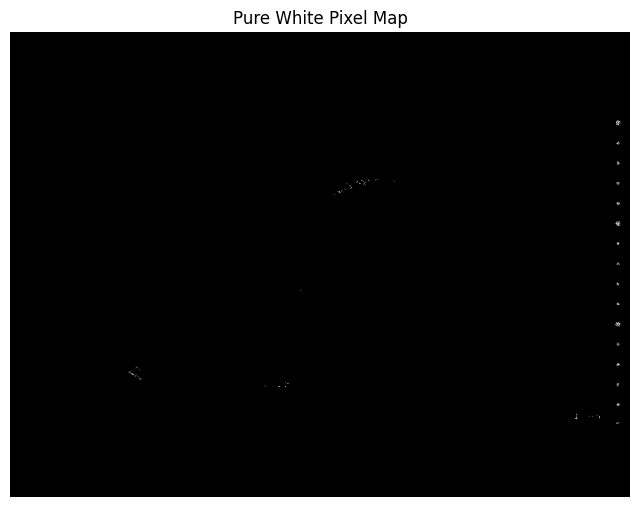

In [ ]:
#show mask


image_path = '/content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/P012/T2/P012_Abd_T2/capture_1_2026-03-19T10-29-16.jpeg'

# Load image
image = cv2.imread(image_path)

if image is None:
    raise ValueError(f"Could not load image: {image_path}")

# Find pure black pixels (B=0, G=0, R=0)
black_mask = np.all(image == 255, axis=2)
black_pixel_map = (black_mask * 255).astype(np.uint8)

# Display in notebook
plt.figure(figsize=(8, 8))
plt.imshow(black_pixel_map, cmap='gray')
plt.title('Pure White Pixel Map')
plt.axis('off')
plt.show()

In [ ]:
# Check video frame counts


VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".webm", ".flv", ".m4v"}
MAX_WORKERS = 8

def get_frame_count(file_path):
    """
    Returns total frame count using ffprobe.
    """
    cmd = [
        "ffprobe",
        "-v", "error",
        "-select_streams", "v:0",
        "-count_frames",
        "-show_entries", "stream=nb_read_frames",
        "-of", "default=noprint_wrappers=1:nokey=1",
        file_path
    ]

    try:
        output = subprocess.check_output(
            cmd,
            stderr=subprocess.DEVNULL
        ).decode().strip()

        return int(output)
    except Exception:
        return None


# Collect video files
video_files = []
for root, dirs, files in os.walk(FOLDER_PATH):
    for file in files:
        ext = os.path.splitext(file.lower())[1]
        if ext in VIDEO_EXTS:
            video_files.append(os.path.join(root, file))

print(f"Found {len(video_files)} video files.")

# Process 5, skip 200
video_files = [
    fp for i, fp in enumerate(sorted(video_files))
    if (i % 205) < 5
]

print(f"Sampling {len(video_files)} videos.\n")

results = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {
        executor.submit(get_frame_count, fp): fp
        for fp in video_files
    }

    for i, future in enumerate(as_completed(futures), 1):
        file_path = futures[future]
        frame_count = future.result()

        if frame_count is not None:
            results.append((file_path, frame_count))

        if i % 10 == 0:
            print(f"Progress: {i}/{len(video_files)}")


if not results:
    print("No valid videos found.")
else:
    frame_counts = [fc for _, fc in results]

    print("\n=== Per-video Frame Counts ===")
    for file_path, frame_count in sorted(results):
        print(f"{frame_count:6d} frames  |  {file_path}")

    print("\n=== Summary Statistics ===")
    print(f"Videos analyzed: {len(frame_counts)}")
    print(f"Average frames : {mean(frame_counts):.2f}")
    print(f"Minimum frames : {min(frame_counts)}")
    print(f"Maximum frames : {max(frame_counts)}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Found 2575 video files.
Sampling 65 videos.

Progress: 10/65
Progress: 20/65
Progress: 30/65
Progress: 40/65
Progress: 50/65
Progress: 60/65

=== Per-video Frame Counts ===
   243 frames  |  /content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/NP001/NP001_Abd/capture_10_2025-12-09T15-24-53.mp4
   243 frames  |  /content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/NP001/NP001_Abd/capture_11_2025-12-09T15-25-09.mp4
   243 frames  |  /content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/NP001/NP001_Abd/capture_12_2025-12-09T15-25-29.mp4
   243 frames  |  /content/drive/Shareddrives/Ranger Lab/Maternal Project/Ultrasound Files/NP001/NP001_Abd/capture_7_2025-12-09T15-23-42.mp4
   243 frames  |  /content/drive/Shareddrives/Ranger Lab/Maternal Proje